In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [91]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos = {i:s for s,i in stoi.items()}
vocab_size= len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [92]:
block_size = 3

def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = [0]*block_size
        for ch in w+'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context),'---->', itos[ix])
            context = context[1:]+[ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [40]:
#--------------Formatted------------------

In [95]:
n_embd = 10 #Dimensionality of the character embedding vector
n_hidden = 200 # The number of neurons in hidden layer
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embd), generator=g)
W1 = torch.randn((n_embd * block_size,n_hidden),generator=g)
b1 = torch.randn(n_hidden,generator=g)
W2 = torch.randn((n_hidden,vocab_size),generator=g)
b2 = torch.randn(vocab_size,generator=g)
parameters = [C,W1,b1,W2,b2]
print(sum(p.nelement() for p in parameters) )
for p in parameters:
    p.requires_grad = True

11897


In [74]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [75]:
    #counts = logits.exp()
    #prob = counts/ counts.sum(1, keepdims=True)
    #loss = -prob[torch.arange(32), Y].log().mean()
    #loss = F.cross_entropy(logits, Y[ix]) # Optimized way to do the above three lines operation [Fused kernels] [Optimized for Forward/backward pass]

In [76]:
lri = []
stepi = []

In [81]:
max_steps = 200000
batch_size = 32
lossi = []
for i in range(200000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0],(batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] 
    # Forward Pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh( @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix]) # exp,log,mean, -ve [Negative log likelihood loss]
    
    # Backward Pass
    for p in parameters:
        p.grad=None
    loss.backward()
    
    #update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr*p.grad
    
    # Track Learning Rate
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())


2.3949484825134277


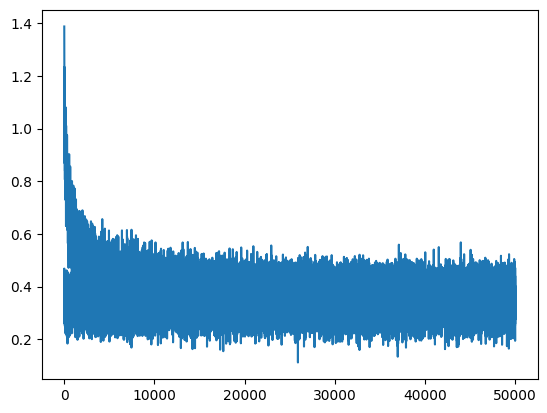

In [82]:
 plt.plot(stepi, lossi)

In [83]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev) # exp,log,mean, -ve [Negative log likelihood loss]
loss    

tensor(2.1908, grad_fn=<NllLossBackward0>)

In [84]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr) # exp,log,mean, -ve [Negative log likelihood loss]
loss  

tensor(2.1641, grad_fn=<NllLossBackward0>)

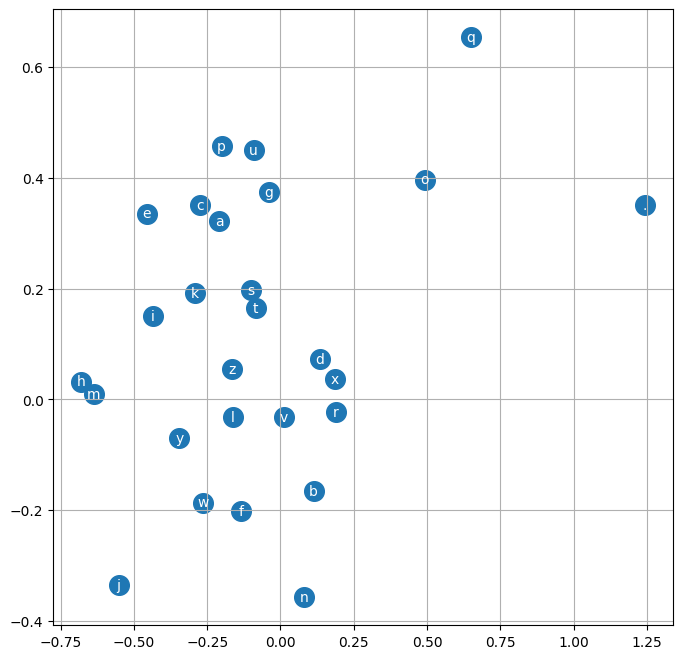

In [85]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data,s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha="center",va="center",color="white")
plt.grid("minor")

In [30]:
#dataset should be divided into three splits which are: Training split [Train Parameters], Dev/Validation split [Train Hyperparameters], Test split [Loss evaluation]
# 80%,10%,10%

In [90]:
g = torch.Generator().manual_seed(2147483647+10)
for _ in range(200):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] #(1,block_size,d)
        h = torch.tanh(emb.view(1,-1) @ W1+b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs,num_samples=1,generator=g).item()
        context = context[1:]+[ix]
        out.append(ix)
        if ix==0:
            break
    print(''.join(itos[i] for i in out))

mora.
mayanniee.
mad.
ryah.
rethan.
brerlee.
adelynneliianni.
jen.
eden.
van.
naraelynn.
houra.
noshebergahimier.
kindrenelvinn.
purrius.
macdis.
yarue.
els.
kaysh.
steyan.
hil.
salynn.
ufezaj.
lujuann.
cry.
kivekoen.
prid.
rahyko.
obin.
prick.
katey.
con.
rarleia.
kiri.
cyprewalla.
ortarayvin.
deon.
asalingt.
dabis.
viu.
meliane.
armoyseanna.
damarienna.
kynn.
tutt.
ive.
dihadirle.
ajayerange.
aldy.
cramiia.
jolon.
et.
jynn.
lory.
pory.
novian.
osi.
maryona.
jayton.
jame.
jaycano.
vio.
maliyana.
brep.
candin.
nichielandos.
gorxton.
rockle.
omaro.
katn.
azren.
ana.
kynn.
taresserosa.
saias.
nic.
cilynan.
zard.
abila.
mawi.
azalenee.
ter.
havelys.
lui.
zyn.
adirai.
jund.
traylinestaftick.
soriane.
merizy.
adylean.
makombane.
bariah.
athawiin.
do.
beejanas.
junne.
taxearti.
yumari.
jamaelif.
siden.
emy.
korin.
garyel.
riyaya.
romina.
malbe.
tevicee.
levalejidlan.
ahryn.
kaylin.
lad.
malandigw.
sta.
awsina.
jaxsneeah.
hayni.
pondam.
gatthia.
addi.
ded.
desto.
iaz.
zai.
arilynn.
malyn.
fa.